## Project 2

Coin tray
12 points total

### Program 1

Find and draw contours over each coin in images tray[1-8.jpg].
Count (and display) how many coins are:
1. Large and inside the tray
2. Large and outside of the tray
3. Small and inside the tray
4. Small and outside of the tray

Calculate and display the area of the tray.

Figure 1: Example output of Program 1 (image tray2.jpg)
Grading
- 2 points - Finding the contour of the tray and calculating its area.
- 4 points - Use of Hough transform to find as many coins as possible∗
- 1 point - Differentiating coins inside and outside of the tray.
- 1 point - Differentiating small and large coins.
- up to 4 points - Tuning the algorithm to work correctly on all images

12 points total.

loading image from disk

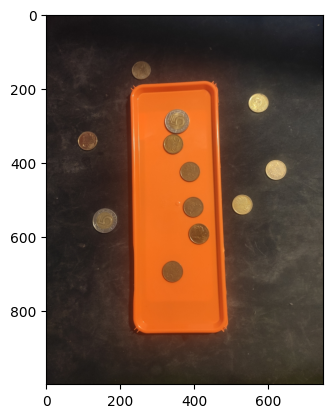

In [149]:
import cv2 as cv
import sys

import numpy as np
from matplotlib import pyplot as plt

def get_original_image():
    image = cv.imread(cv.samples.findFile("resources/tray4.jpg"))

    if image is None:
        sys.exit("Could not read the image.")

    return image

original_image_with_hough_alg = get_original_image()

converted_for_display = cv.cvtColor(original_image_with_hough_alg, cv.COLOR_BGR2RGB)

plt.imshow(converted_for_display)

conversion to hsv for easier processing

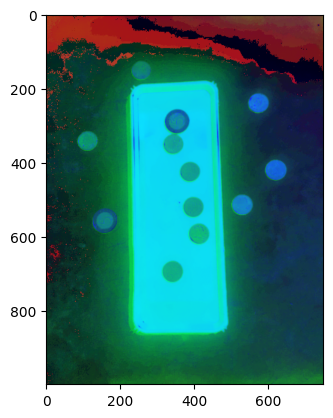

In [150]:
img = cv.cvtColor(original_image_with_hough_alg, cv.COLOR_BGR2HSV)
plt.imshow(img)

apply filtering mask

basic red color code in hsv, for reference [[[120 255 255]]]


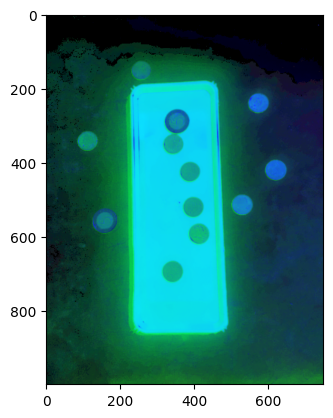

In [151]:
red = np.uint8([[[255,0,0 ]]])
hsv_red = cv.cvtColor(red, cv.COLOR_BGR2HSV)
print("basic red color code in hsv, for reference " + str(hsv_red))

lower_red = np.array([50, 0, 0], np.uint8)
upper_red = np.array([230, 255, 255], np.uint8)

mask = cv.inRange(img, lower_red, upper_red)
mask_inv = cv.bitwise_not(mask)

img = cv.bitwise_and(img, img, mask=mask_inv)

plt.imshow(mask)
plt.imshow(img)

casting to gray scale and blurring

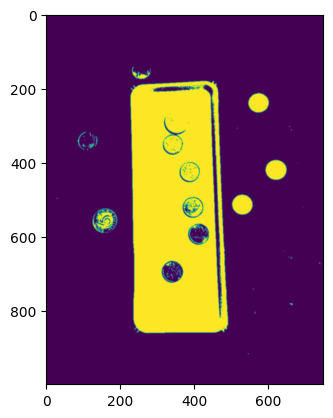

In [152]:
img_as_bgr = cv.cvtColor(img, cv.COLOR_HSV2BGR)
img_as_grey = cv.cvtColor(img_as_bgr, cv.COLOR_BGR2GRAY)
ret, img_with_threshold = cv.threshold(img_as_grey, 100, 255, 0)

blurred_image = cv.GaussianBlur(img_with_threshold,(5,5),0)

plt.imshow(blurred_image)

find edges

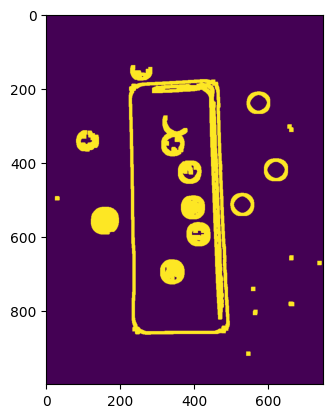

In [140]:
edges = cv.Canny(blurred_image,20,255)

kernel = np.ones((3,3),np.uint8)
dilated_edges = cv.dilate(edges,kernel,iterations = 4)
edges = dilated_edges

plt.imshow(edges)

find contours

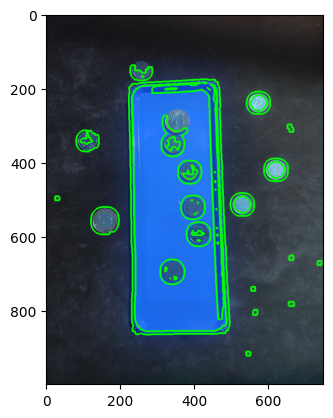

In [155]:
contours, hierarchy = cv.findContours(edges, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)
original_image_with_contours = get_original_image()
cv.drawContours(original_image_with_contours, contours, -1, (0,255,0), 3)
plt.imshow(original_image_with_contours)

filter pixel-sized contours

In [176]:
contour_areas = [cv.contourArea(cnt) for cnt in contours]

filtered_contours = []

for contour, area in zip(contours, contour_areas):
    if area > 300:
        filtered_contours.append(contour)

filtered_contours.sort(key=lambda x: cv.contourArea(x), reverse=True)
filtered_contours_areas = [cv.contourArea(cnt) for cnt in filtered_contours]
print(filtered_contours_areas)

[171049.0, 140478.5, 4598.0, 4403.5, 3611.0, 3496.0, 3452.0, 3330.5, 3320.5, 3288.5, 3170.5, 2352.0, 1553.5, 1544.0, 1502.5, 1430.5, 788.5, 781.0, 558.5]


label and count coins

In [168]:
original_image_with_contours = get_original_image()

# box from 200 000 to 180 000
box_area = lambda area: 180_000 <= area <= 200_000
box_contours: list = [[contour for contour in filtered_contours if box_area(cv.contourArea(contour))][0]]
cv.drawContours(original_image_with_contours, box_contours, -1, (255,0,0), 3)

# big nominals from 6000 to 4000
big_nominal_area = lambda area: 4_000 <= area <= 6_000
big_nominal_contours: list = [contour for contour in filtered_contours if big_nominal_area(cv.contourArea(contour))]
number_of_big_nominal_coins = len(big_nominal_contours)
cv.drawContours(original_image_with_contours, big_nominal_contours, -1, (255,255,10), 3)

# small nominals from 4000 to 2000
small_nominal_area = lambda area: 2_000 <= area <= 4_000
small_nominal_contours: list = [contour for contour in filtered_contours if small_nominal_area(cv.contourArea(contour))]
number_of_small_nominal_coins = len(small_nominal_contours)
cv.drawContours(original_image_with_contours, small_nominal_contours, -1, (0,255,0), 3)

plt.imshow(original_image_with_contours)
plt.title('#small nominal coins: ' + str(number_of_small_nominal_coins) + ' | #big nominal coins: ' + str(number_of_big_nominal_coins))

IndexError: list index out of range

find circles using Hough algorithm

In [158]:
min_radius_of_small_nominal_coin: int = 20
max_radius_of_big_nominal_coin: int = 40


circles = cv.HoughCircles(img_with_threshold,
                          cv.HOUGH_GRADIENT,
                          1,
                          minDist=min_radius_of_small_nominal_coin * 2,
                          param1=1,
                          param2=15,
                          minRadius=min_radius_of_small_nominal_coin,
                          maxRadius=max_radius_of_big_nominal_coin)

circles = np.uint16(np.around(circles))
print(circles)

[[[156 560  31]
  [396 522  25]
  [412 594  28]
  [340 694  27]
  [620 420  28]
  [386 428  26]
  [528 516  27]
  [574 240  26]
  [342 350  24]
  [352 292  33]
  [110 344  21]
  [260 150  24]]]


label circles and count them

In [159]:
original_image_with_hough_alg = get_original_image()

margin_error: int = 11
is_small_nominal_coin = lambda circle: min_radius_of_small_nominal_coin <= circle[2] <= min_radius_of_small_nominal_coin + margin_error
is_big_nominal_coin = lambda circle: max_radius_of_big_nominal_coin - margin_error <= circle[2] <= max_radius_of_big_nominal_coin

count_of_small_nominal_coins: int = 0
count_of_big_nominal_coins: int = 0

for circle in circles[0,:]:
    if is_small_nominal_coin(circle):
        cv.circle(original_image_with_hough_alg, (circle[0], circle[1]), circle[2], (0, 255, 0), 2)
        count_of_small_nominal_coins += 1
    else:
        if is_big_nominal_coin(circle):
            cv.circle(original_image_with_hough_alg, (circle[0], circle[1]), circle[2], (255, 255, 0), 2)
            count_of_big_nominal_coins += 1

draw contour of the box and count coins inside

[396 522  25]
[412 594  28]
[340 694  27]
[386 428  26]
[342 350  24]
[352 292  33]


Text(0.5, 1.0, '#small nominal coins: 11 | #big nominal coins: 1')

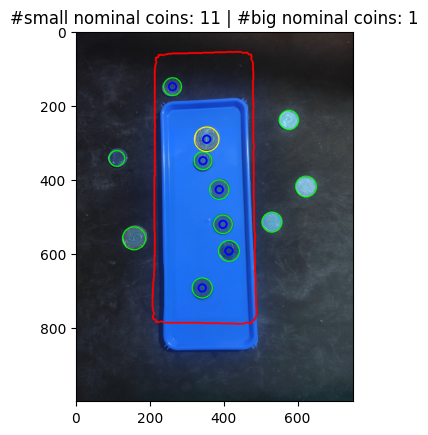

In [182]:
box_area = lambda area: 170_000 <= area <= 200_000
box_contour = [contour for contour in filtered_contours if box_area(cv.contourArea(contour))][0]
cv.drawContours(original_image_with_hough_alg, box_contours, -1, (255,0,0), 3)


for circle in circles[0,:]:
    if 1 == cv.pointPolygonTest(box_contour, (circle[0], circle[1]), False):
        print(circle)
        cv.circle(original_image_with_hough_alg,(circle[0],circle[1]),10,(0,0,255),3)

plt.imshow(original_image_with_hough_alg)
plt.title('#small nominal coins: ' + str(count_of_small_nominal_coins) + ' | #big nominal coins: ' + str(count_of_big_nominal_coins))
